Submitted by Marielle Alexa Salvador

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Title Extraction and Analysis
Task: Extract the title (e.g., Mr., Miss, Master) from the Name column and determine the survival rate for each title.

In [ ]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
print("Unique Titles:", df['Title'].unique())
title_survival = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
print(f"Survival rate by title:")
print(title_survival)

Unique Titles: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']
Survival rate by title:
Title
Lady            1.000000
Ms              1.000000
Sir             1.000000
Mme             1.000000
the Countess    1.000000
Mlle            1.000000
Mrs             0.792000
Miss            0.697802
Master          0.575000
Major           0.500000
Col             0.500000
Dr              0.428571
Mr              0.156673
Capt            0.000000
Jonkheer        0.000000
Don             0.000000
Rev             0.000000
Name: Survived, dtype: float64


#Cabin Grouping
Task:
Group passengers based on the first letter of their Cabin (e.g., A, B, C...) and compute:

Total passengers

Survival rate per cabin group

In [ ]:
df['CabinGroup'] = df['Cabin'].str[0].fillna('Unknown')

cabin_group_analysis = df.groupby('CabinGroup').agg(
    Total_Passengers=('PassengerId', 'count'),
    Survival_Rate=('Survived', 'mean')
).sort_values(by='Total_Passengers', ascending=False)

print("Analysis by Cabin Group:")
print(cabin_group_analysis)

Analysis by Cabin Group:
            Total_Passengers  Survival_Rate
CabinGroup                                 
Unknown                  687       0.299854
C                         59       0.593220
B                         47       0.744681
D                         33       0.757576
E                         32       0.750000
A                         15       0.466667
F                         13       0.615385
G                          4       0.500000
T                          1       0.000000


#Family Size Impact
Task:
Create a new column FamilySize = SibSp + Parch + 1 and categorize family size as:

'Single' (1)

'Small' (2–4)

'Large' (5+)

Then compute survival rates for each category.

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

def categorize_family_size(size):
    if size == 1:
        return 'Single'
    elif 2 <= size <= 4:
        return 'Small'
    else:
        return 'Large'

df['FamilySizeCategory'] = df['FamilySize'].apply(categorize_family_size)

family_size_survival = df.groupby('FamilySizeCategory')['Survived'].mean().sort_values(ascending=False)

print("Survival rate by Family Size Category:")
print(family_size_survival)

Survival rate by Family Size Category:
FamilySizeCategory
Small     0.578767
Single    0.303538
Large     0.161290
Name: Survived, dtype: float64


#Age Binning and Survival Analysis
Task:
Create age bins: [0–10], [11–20], ..., [71+] and use .cut() to assign age groups. Plot the survival rate by age group.

/tmp/ipython-input-1019644766.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_survival = df.groupby('AgeGroup')['Survived'].mean()


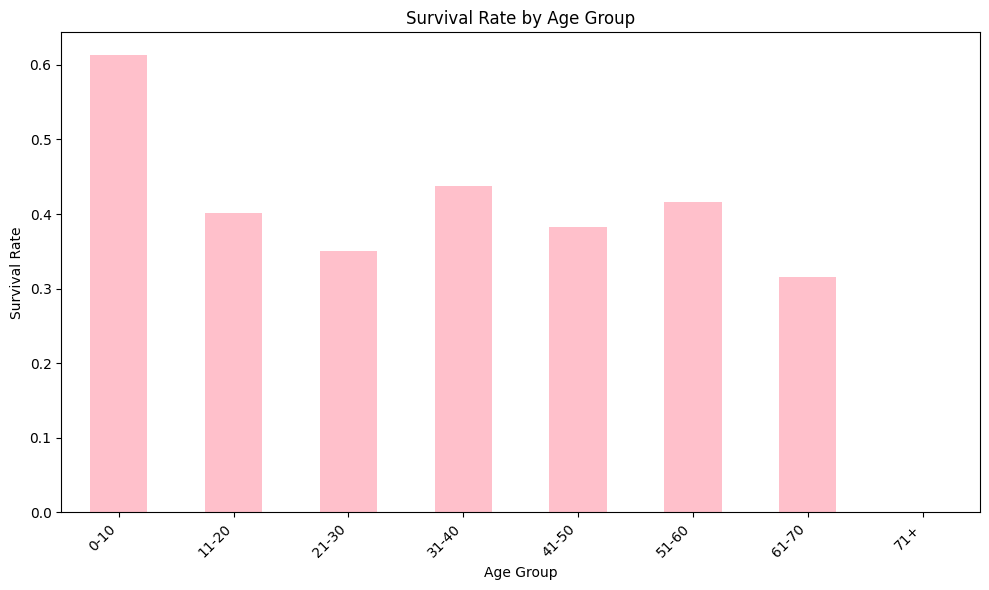

In [ ]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71+']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
age_group_survival = df.groupby('AgeGroup')['Survived'].mean()

plt.figure(figsize=(10, 6))
age_group_survival.plot(kind='bar', color = 'pink')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Cross Tab: Class vs. Sex vs. Survival
Task: Create a pivot table showing survival counts and rates grouped by both Pclass and Sex.

In [ ]:
pivot_table_pclass_sex = pd.pivot_table(df, values='Survived', index=['Pclass', 'Sex'], aggfunc=['count', 'mean'])

print("Survival analysis by Pclass and Sex:")
print(pivot_table_pclass_sex)

Survival analysis by Pclass and Sex:
                 count      mean
              Survived  Survived
Pclass Sex                      
1      female       94  0.968085
       male        122  0.368852
2      female       76  0.921053
       male        108  0.157407
3      female      144  0.500000
       male        347  0.135447


#Impute Missing Age Using Median per Title
Task: Use the Title extracted in Exercise 1 to impute missing Age values with the median age of each title group.

In [ ]:
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
print(f"Missing age values after imputation are {df['Age'].isnull().sum()}")

Missing age values after imputation are 0


#Correlation Heatmap of Encoded Features
Task: Encode Sex, Embarked, and Title using .map() or pd.get_dummies(), and compute a correlation matrix to see which features most strongly correlate with Survived.

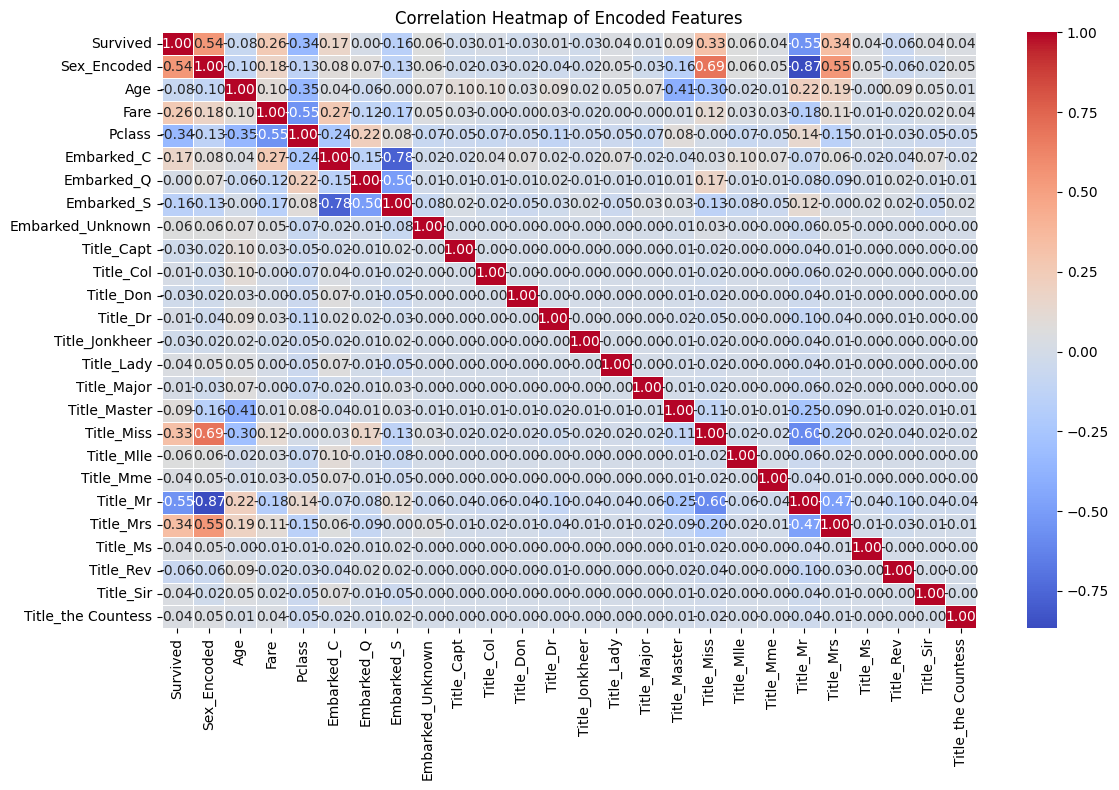

In [ ]:
import seaborn as sns

df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].fillna('Unknown')
embarked_variables = pd.get_dummies(df['Embarked'], prefix='Embarked')
new_title = pd.get_dummies(df['Title'], prefix='Title')

df_encoded = pd.concat([df, embarked_variables, new_title], axis=1)
corr_features = ['Survived', 'Sex_Encoded', 'Age', 'Fare', 'Pclass'] + list(embarked_variables.columns) + list(new_title.columns)
correlation_matrix = df_encoded[corr_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Encoded Features')
plt.tight_layout()
plt.show()

#Identify Duplicate Ticket Holders
Task: Group passengers by Ticket number and identify tickets shared by multiple passengers. For these, compute the survival rate of all passengers sharing the same ticket.

In [ ]:
ticket_counts = df.groupby('Ticket').size()
shared_tickets = ticket_counts[ticket_counts > 1].index
df_shared_tickets = df[df['Ticket'].isin(shared_tickets)]
shared_ticket_survival = df_shared_tickets.groupby('Ticket')['Survived'].mean().sort_values(ascending=False)

print("Survival rate for passengers sharing the same ticket:")
print(shared_ticket_survival)

Survival rate for passengers sharing the same ticket:
Ticket
110152          1.0
111361          1.0
113572          1.0
113505          1.0
113806          1.0
               ... 
CA. 2343        0.0
S.O.C. 14879    0.0
S.O./P.P. 3     0.0
W./C. 6607      0.0
W./C. 6608      0.0
Name: Survived, Length: 134, dtype: float64


#Analyze Fare per Person
Task: Calculate a new column FarePerPerson = Fare / FamilySize. Analyze the correlation between FarePerPerson and Survived.

In [ ]:
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
fare_corr = df[['FarePerPerson', 'Survived']].corr()
print(f"Correlation between Fare Per Person and Survived")
print(fare_corr)

Correlation between Fare Per Person and Survived
               FarePerPerson  Survived
FarePerPerson         1.0000    0.2216
Survived              0.2216    1.0000


#Feature Interaction: Class and Fare
Task: Create a new categorical feature that combines Pclass and fare quantiles (e.g., '1_HighFare', '2_LowFare', etc.). Analyze survival across these new categories.

In [ ]:
df['FareQuantile'] = pd.qcut(df['Fare'], q=4, labels=['LowFare', 'MediumLowFare', 'MediumHighFare', 'HighFare'])
df['Pclass_Fare'] = df['Pclass'].astype(str) + '_' + df['FareQuantile'].astype(str)
pclass_fare_survival = df.groupby('Pclass_Fare')['Survived'].mean().sort_values(ascending=False)

print("Survival rate by Pclass and Fare Quantile:")
print(pclass_fare_survival)

Survival rate by Pclass and Fare Quantile:
Pclass_Fare
1_HighFare          0.685535
2_MediumHighFare    0.600000
2_HighFare          0.545455
1_MediumHighFare    0.529412
2_MediumLowFare     0.383721
3_MediumHighFare    0.316832
3_MediumLowFare     0.253623
3_LowFare           0.208531
3_HighFare          0.195122
1_LowFare           0.000000
2_LowFare           0.000000
Name: Survived, dtype: float64
